# 권효중, KDT 12기 취업 조건, 회사 추천
## 빅데이터/AI 소프트웨어 분야 조사

In [48]:
from urllib.request import urlopen,Request
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
import pandas as pd
from selenium.webdriver.support import expected_conditions as EC
import time
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import koreanize_matplotlib
from PIL import Image
from wordcloud import WordCloud
from konlpy.tag import Okt
import platform

### 자소설 사이트 데이터 분석

In [ ]:
# 자소설 부문 분석
df2 = pd.read_csv('jasoseol.csv',encoding='utf-8')
df2

,Unnamed: 0,회사,업종,전공,학점,토익,자격증
0,0,아마존웹서비스,"전문, 과학 및 기술 서비스업","['전산학ㆍ컴퓨터공학', '경영학', '산업공학', '응용소프트웨어공학', '통계학...",3.8,837.0,"['정보처리기사', 'ADsP', 'SQLD', '빅데이터분석기사', '자동차운전면..."
1,1,디와이,서비스업,"['전자공학', '전산학ㆍ컴퓨터공학', '응용소프트웨어공학', '기계공학', '국제...",3.7,823.0,"['자동차운전면허 1종 보통', '화학분석기능사', '산업안전산업기사', '위험물산..."
2,2,한국건설생활환경시험연구원,NaN,"['화학공학', '경영학', '기계공학', '신소재공학', '화학', '전자공학']",3.6,806.4,"['한국사능력검정시험 1급', '자동차운전면허 2종 보통', '컴퓨터활용능력1급',..."
3,3,효성그룹,NaN,"['경영학', '화학공학', '기계공학', '전자공학', '전기공학', '전산학ㆍ컴...",3.8,855.4,"['컴퓨터활용능력1급', '자동차운전면허 2종 보통', 'ADsP', '한국사능력검..."
4,4,한국서부발전(wp),발전업,"['기계공학', '전기공학', '경영학', '전자공학', '화학공학', '경제학']",3.7,834.4,"['한국사능력검정시험 1급', '컴퓨터활용능력1급', '전기기사', '한국사능력검정..."
...,...,...,...,...,...,...,...
147,147,한국항공우주산업,제조업,"['기계공학', '전자공학', '경영학', '화학공학', '전기공학', '신소재공학']",3.8,848.8,"['자동차운전면허 1종 보통', '컴퓨터활용능력1급', 'ADsP', '자동차운전면..."
148,148,우리은행,금융 및 보험업,"['경영학', '전산학ㆍ컴퓨터공학', '경제학', '응용소프트웨어공학', '무역ㆍ유...",3.8,856.9,"['ADsP', 'SQLD', '정보처리기사', '한국사능력검정시험 1급', '투자..."
149,149,파수,정보통신업,"['전산학ㆍ컴퓨터공학', '응용소프트웨어공학', '정보ㆍ통신공학', '경영학', '...",3.7,831.9,"['정보처리기사', 'SQLD', 'ADsP', '컴퓨터활용능력1급', '자동차운전..."
150,150,KT스카이라이프,정보통신업,"['전산학ㆍ컴퓨터공학', '경영학', '정보ㆍ통신공학', '응용소프트웨어공학', '...",3.7,851.5,"['정보처리기사', 'SQLD', 'ADsP', '컴퓨터활용능력1급', '자동차운전..."


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\815284165.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('rainbow')


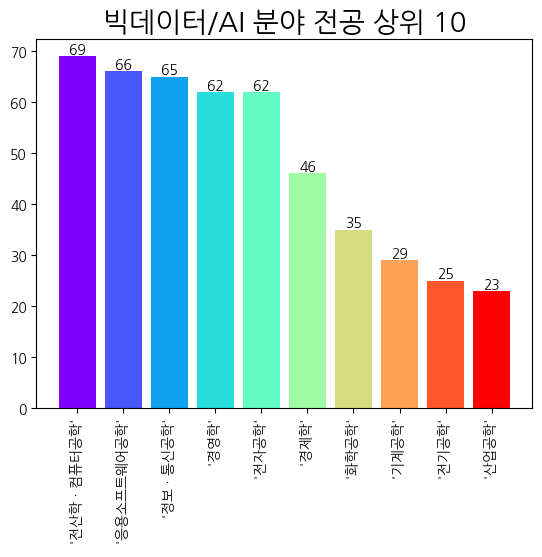

In [50]:
# 전공 상위
major_str=''
for i in df2['전공']:
    major_str += i.replace('[','').replace(']','')
major_list = major_str.split(',')

major_list2 = Counter(major_list).most_common(10)
majors = [major[0] for major in major_list2]
counts = [major[1] for major in major_list2]
cmap = plt.cm.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(majors,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('빅데이터/AI 분야 전공 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\939548157.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('rainbow')


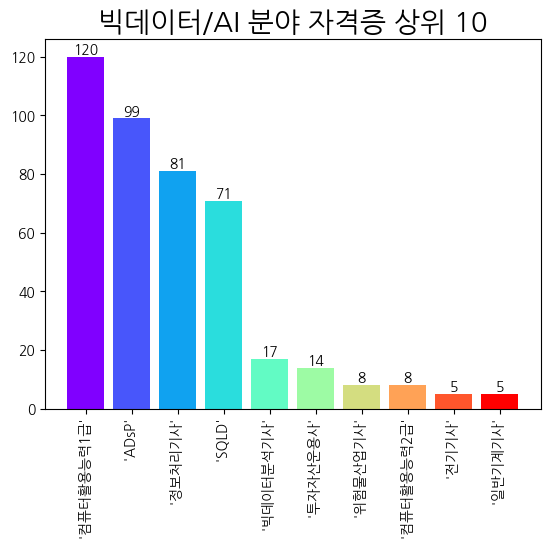

In [51]:
# 자격증 상위 10개
qual_str=''
for i in df2['자격증']:
    qual_str += i.replace('[','').replace(']','')
qual_list = qual_str.split(',')
qual_list = [x for x in qual_list if '자동차' not in x and '한국사' not in x]
qual_list2 = Counter(qual_list).most_common(10)

quals = [qual[0] for qual in qual_list2]
counts = [qual[1] for qual in qual_list2]
cmap = plt.cm.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(quals,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('빅데이터/AI 분야 자격증 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\4030906715.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('rainbow')


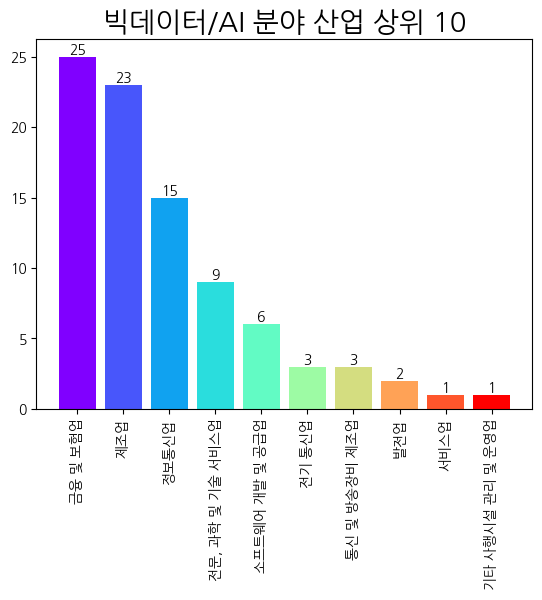

In [52]:
# 업종 상위

industry_list = []
for i in df2['업종'].dropna():
    industry_list.append(i)

industry_list2 = Counter(industry_list).most_common(10)
industrys = [industry[0] for industry in industry_list2]
counts = [industry[1] for industry in industry_list2]
cmap = plt.cm.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(industrys,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('빅데이터/AI 분야 산업 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()



In [ ]:
print('토익 평균: ',df2['토익'].mean())
print('학점 평균: ',df2['학점'].mean())
# 토익, 학점 평균 계산

토익 평균:  846.621052631579
학점 평균:  3.7374999999999994


### catch 사이트 데이터 분석

In [ ]:
# catch 사이트에서 불러온 데이터 분석
df = pd.read_csv('catch4.csv')
df = df.drop_duplicates()
df = df.reset_index(drop = True)
df = df.replace('%','',regex=True)
df[['리뷰1점수','리뷰2점수','리뷰3점수','리뷰4점수','리뷰5점수']] = df[['리뷰1점수','리뷰2점수','리뷰3점수','리뷰4점수','리뷰5점수']].astype(float)
df_score = df.dropna()

# 5점 만점의 점수만 추출
df_score['급여'] = df_score['급여'].str[:3]
df_score['조직문화'] = df_score['조직문화'].str[:3]
df_score['워라밸'] = df_score['워라밸'].str[:3]
df_score['커리어'] = df_score['커리어'].str[:3]
df_score['경영진'] = df_score['경영진'].str[:3]
df_score[['급여','조직문화','워라밸','커리어','경영진']] = df_score[['급여','조직문화','워라밸','커리어','경영진']].astype(float)
df_score
df_score = df_score.drop_duplicates(subset='회사')
df_score

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\843602868.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['급여'] = df_score['급여'].str[:3]
C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\843602868.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['조직문화'] = df_score['조직문화'].str[:3]
C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\843602868.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

,회사,업종,공고,특징,종합,급여,조직문화,워라밸,커리어,경영진,리뷰1,리뷰1점수,리뷰2,리뷰2점수,리뷰3,리뷰3점수,리뷰4,리뷰4점수,리뷰5,리뷰5점수
1,경남은행,국내은행,7급 신입행원(보훈전형) 채용,"\n 정보보안, 데이터 엔지니어, 서비스기획/운영...",3.9,4.1,3.9,3.8,3.9,3.9,🤑 성과급이 있어요,86.0,👔 정장을 주로 입어요,46.0,🥽 휴가를 자유롭게 쓸 수 있어요,53.0,💻 커리어 개발이 가능해요,77.0,💪 우리회사는 앞으로 성장할 거예요!,80.0
2,한국기계연구원,기타 공학 연구개발업,2026년도 제1회 신입직원 공개채용,"\n 에너지, 화학, 환경, 머신러닝 엔지니어, ...",4.6,4.6,4.6,4.6,4.6,4.4,🤑 성과급이 있어요,100.0,👔 복장이 자유로워요,67.0,🥽 휴가를 자유롭게 쓸 수 있어요,100.0,💻 커리어 개발이 가능해요,93.0,💪 우리회사는 앞으로 성장할 거예요!,86.0
4,셀트리온,의약용 화합물 및 항생물질 제조업,2026년 AI/신사업 분야 수시채용,"\n 의약품, 바이오, 제약, 자재관리, 생산관리...",4.1,4.2,4.0,4.1,4.2,3.9,🤑 성과급이 있어요,94.0,👔 비즈니스캐주얼을 입어요,68.0,🥽 휴가를 자유롭게 쓸 수 있어요,56.0,💻 커리어 개발이 가능해요,93.0,💪 우리회사는 앞으로 성장할 거예요!,85.0
5,테스,반도체 제조용 기계 제조업,2026 1분기 신입/경력사원 채용,"\n 기계, 반도체, 디스플레이, 공정관리, 생산...",4.2,4.1,4.3,4.1,4.3,4.1,🤑 성과급이 있어요,83.0,👔 복장이 자유로워요,58.0,🥽 휴가를 자유롭게 쓸 수 있어요,71.0,💻 커리어 개발이 가능해요,92.0,💪 우리회사는 앞으로 성장할 거예요!,83.0
6,한독,완제 의약품 제조업,신입 및 경력 직무별 수시채용 (마감일 직무별 상이),"\n 의약품, 인허가업무, 법무, 생산관리, 공정...",4.0,3.9,4.0,4.1,3.9,3.9,🤑 성과급이 있어요,63.0,👔 복장이 자유로워요,50.0,🥽 휴가를 자유롭게 쓸 수 있어요,67.0,💻 커리어 개발이 가능해요,85.0,💪 우리회사는 앞으로 성장할 거예요!,58.0
7,현대로템,기관차 및 기타 철도 차량 제조업,"2월_경력, 신입 수시채용","\n 사업기획, 전략기획, 서비스기획/운영, 일반...",4.0,4.1,4.0,4.1,4.1,3.9,🤑 성과급이 있어요,92.0,👔 복장이 자유로워요,52.0,🥽 휴가를 자유롭게 쓸 수 있어요,61.0,💻 커리어 개발이 가능해요,75.0,💪 우리회사는 앞으로 성장할 거예요!,73.0
10,JYP엔터테인먼트,음악 및 기타 오디오물 출판업,2026 상반기 수시채용,"\n 전략기획, 사업기획, 신규사업/BD, 인허가...",4.0,4.1,4.2,3.9,4.0,4.0,🤑 성과급이 있어요,96.0,👔 복장이 자유로워요,71.0,🥽 휴가를 자유롭게 쓸 수 있어요,36.0,💻 커리어 개발이 가능해요,76.0,💪 우리회사는 앞으로 성장할 거예요!,84.0
12,네이버,포털 및 기타 인터넷 정보 매개 서비스업,AI 검색 기술 연구 및 개발 체험형 인턴 채용,"\n 파이썬 개발자, 프론트엔드 개발자, 자바 개...",4.3,4.4,4.3,4.4,4.4,4.2,🤑 성과급이 있어요,83.0,👔 복장이 자유로워요,61.0,🥽 휴가를 자유롭게 쓸 수 있어요,74.0,💻 커리어 개발이 가능해요,90.0,💪 우리회사는 앞으로 성장할 거예요!,87.0
13,JW홀딩스,지주회사,JW 2026년 2차 수시채용,"\n 신규사업/BD, 사업기획, 전략기획, PM,...",3.8,3.8,3.8,4.3,3.9,3.4,🤑 성과급이 있어요,70.0,👔 비즈니스캐주얼을 입어요,53.0,🥽 휴가를 자유롭게 쓸 수 있어요,100.0,💻 커리어 개발이 가능해요,80.0,💪 우리회사는 앞으로 성장할 거예요!,10.0
14,파수,응용 소프트웨어 개발 및 공급업,2026년 1차 신입 공개채용,"\n 기술영업, B2B영업, 해외마케팅, 마케팅전...",3.8,3.8,4.1,4.1,3.8,3.2,🤑 성과급이 있어요,35.0,👔 복장이 자유로워요,56.0,🥽 휴가를 자유롭게 쓸 수 있어요,63.0,💻 커리어 개발이 가능해요,71.0,💪 우리회사는 앞으로 성장할 거예요!,47.0


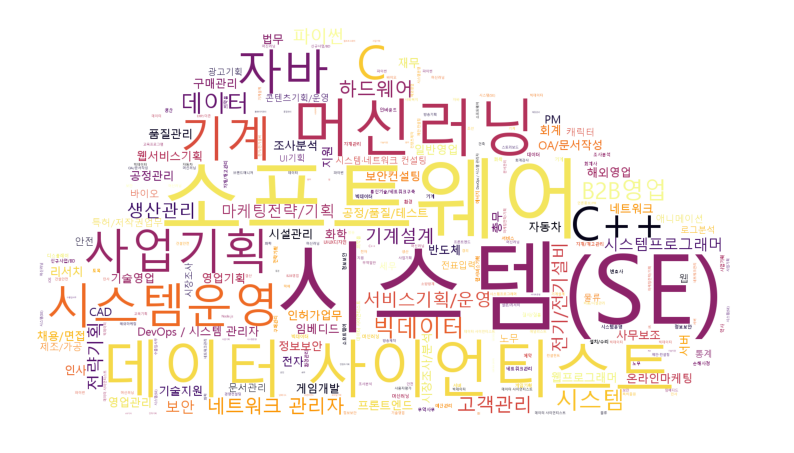

In [ ]:
# word Cloud 생성
# 업무 특징 wordcloud 생성
feature_str=''
for i in df['특징']:
    feature_str += i.replace('\n','').replace('엔지니어','').replace('개발자','')
feature_list = feature_str.split(',')
okt = Okt()
tags = Counter(feature_list)


#한글을 분석하기 위해 font를 한글로 지정
if platform.system() == 'Windows':
    path = r'c:\Windows\Fonts\malgun.ttf'
elif platform.system() == 'Darwin':
    path = r'/System/Library/Fonts/AppleGothic'
else:
    font = r'/user/share/fonts/truetype/name/NanumMyeongjo.ttf'

img_mask = np.array(Image.open('cloud.png'))
wc = WordCloud(font_path=path, width=400,height=400,
               background_color='white',max_font_size=200,
               repeat=True,
               colormap='inferno',mask=img_mask)

cloud = wc.generate_from_frequencies(dict(tags))# 딕셔너리의 value값(빈도수)에 따라 글자 크기가 달라짐
# 생성된 WordCloud를 test.jpg로 보낸다.
# cloud.to_file('test.jpg')
plt.figure(figsize=(10,8))
plt.axis('off')
plt.imshow(cloud)
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\444601758.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


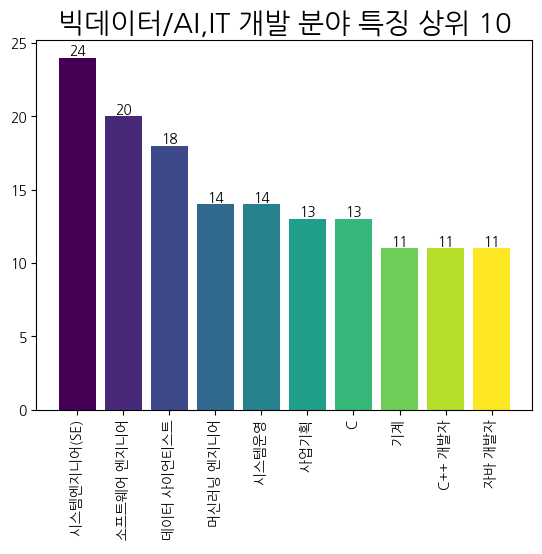

In [ ]:
# 업무 특징 상위 10개
feature_str=''
for i in df['특징']:
    feature_str += i.replace('\n','')
feature_list = feature_str.split(',')

feature_list2 = Counter(feature_list).most_common(10)
features = [feature[0] for feature in feature_list2]
counts = [feature[1] for feature in feature_list2]
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(features,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('빅데이터/AI,IT 개발 분야 특징 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\4170333166.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


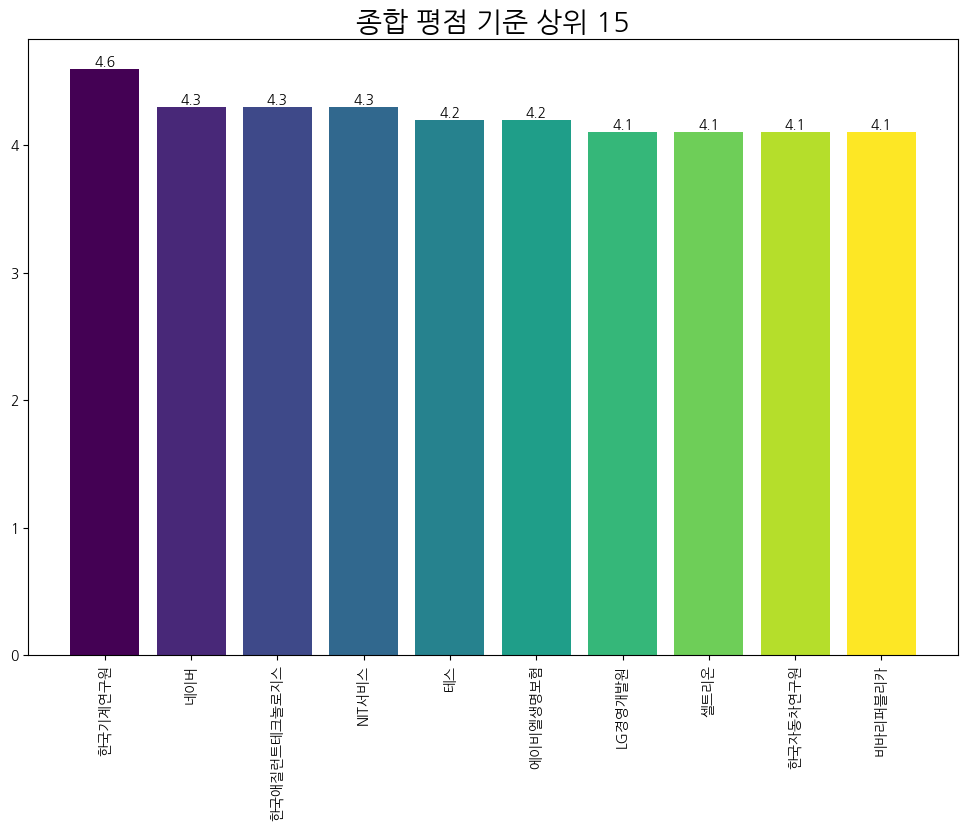

In [57]:
# 종합 점수 상위 15개
df_score1 = df_score[['회사','종합']].sort_values(by = '종합',ascending=False)

cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
plt.figure(figsize=(12,8))
bars = plt.bar(df_score1['회사'][:10],df_score1['종합'][:10],color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('종합 평점 기준 상위 15',size=20)
plt.xticks(rotation=90)
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\1624138369.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


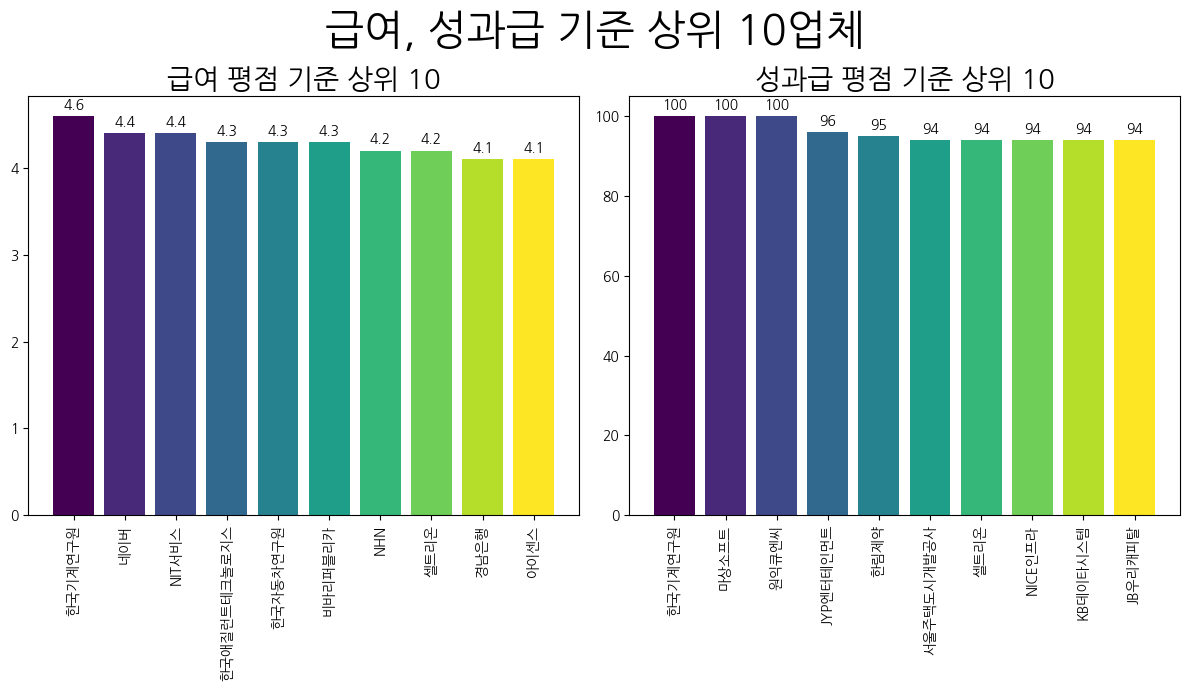

In [58]:
# 급여, 성과급 점수 상위 10개
df_score1= df_score[['회사','급여']].sort_values(by = '급여',ascending=False)
df_score2 = df_score[['회사','리뷰1점수']].sort_values(by = '리뷰1점수',ascending=False)

cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
fig,axes = plt.subplots(1,2,figsize=(12,7))
fig.suptitle('급여, 성과급 기준 상위 10업체',size=30)

bars1 = axes[0].bar(df_score1['회사'][:10], df_score1['급여'][:10],color = colors)
axes[0].bar_label(bars1, padding=3) # padding은 막대와 숫자 사이의 간격
axes[0].set_title('급여 평점 기준 상위 10',size=20)
axes[0].tick_params(axis='x', labelrotation=90)


bars2 = axes[1].bar(df_score2['회사'][:10], df_score2['리뷰1점수'][:10],color = colors)
axes[1].bar_label(bars2, padding=3) # padding은 막대와 숫자 사이의 간격
axes[1].set_title('성과급 평점 기준 상위 10',size=20)
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\1167354641.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


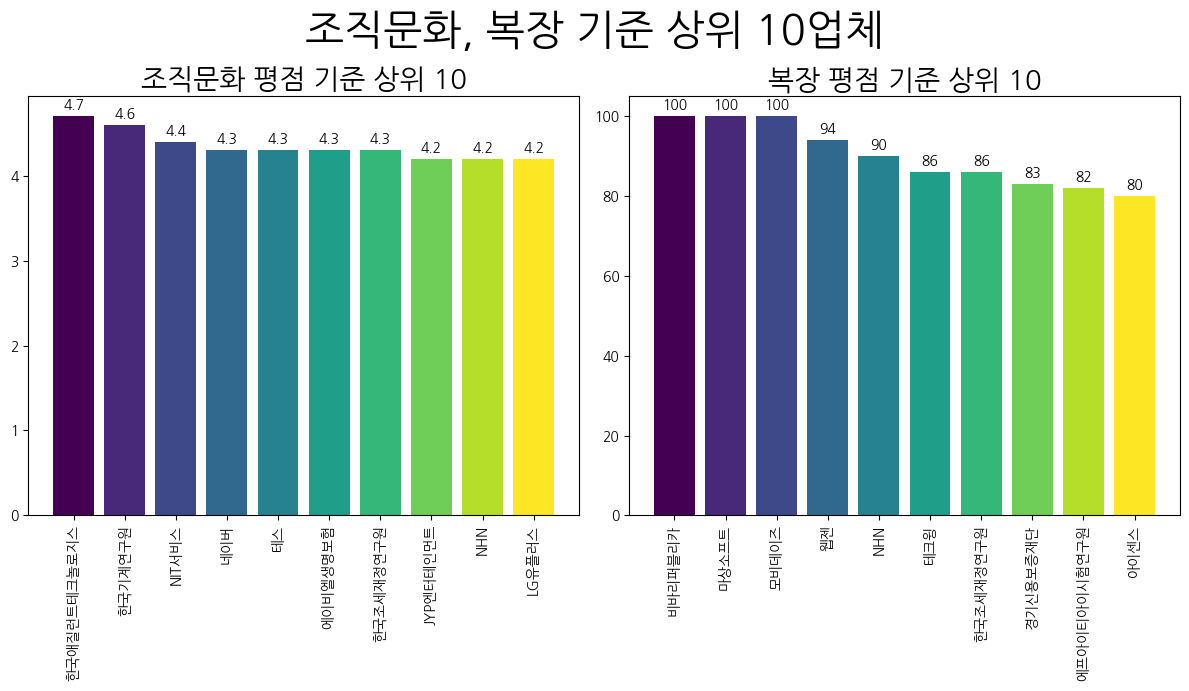

In [59]:
# 조직문화, 복장 점수 상위 10개
df_score1= df_score[['회사','조직문화']].sort_values(by = '조직문화',ascending=False)
df_score2 = df_score[['회사','리뷰2점수']].sort_values(by = '리뷰2점수',ascending=False)

cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
fig,axes = plt.subplots(1,2,figsize=(12,7))
fig.suptitle('조직문화, 복장 기준 상위 10업체',size=30)

bars1 = axes[0].bar(df_score1['회사'][:10], df_score1['조직문화'][:10],color = colors)
axes[0].bar_label(bars1, padding=3) # padding은 막대와 숫자 사이의 간격
axes[0].set_title('조직문화 평점 기준 상위 10',size=20)
axes[0].tick_params(axis='x', labelrotation=90)


bars2 = axes[1].bar(df_score2['회사'][:10], df_score2['리뷰2점수'][:10],color = colors)
axes[1].bar_label(bars2, padding=3) # padding은 막대와 숫자 사이의 간격
axes[1].set_title('복장 평점 기준 상위 10',size=20)
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\1702963579.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


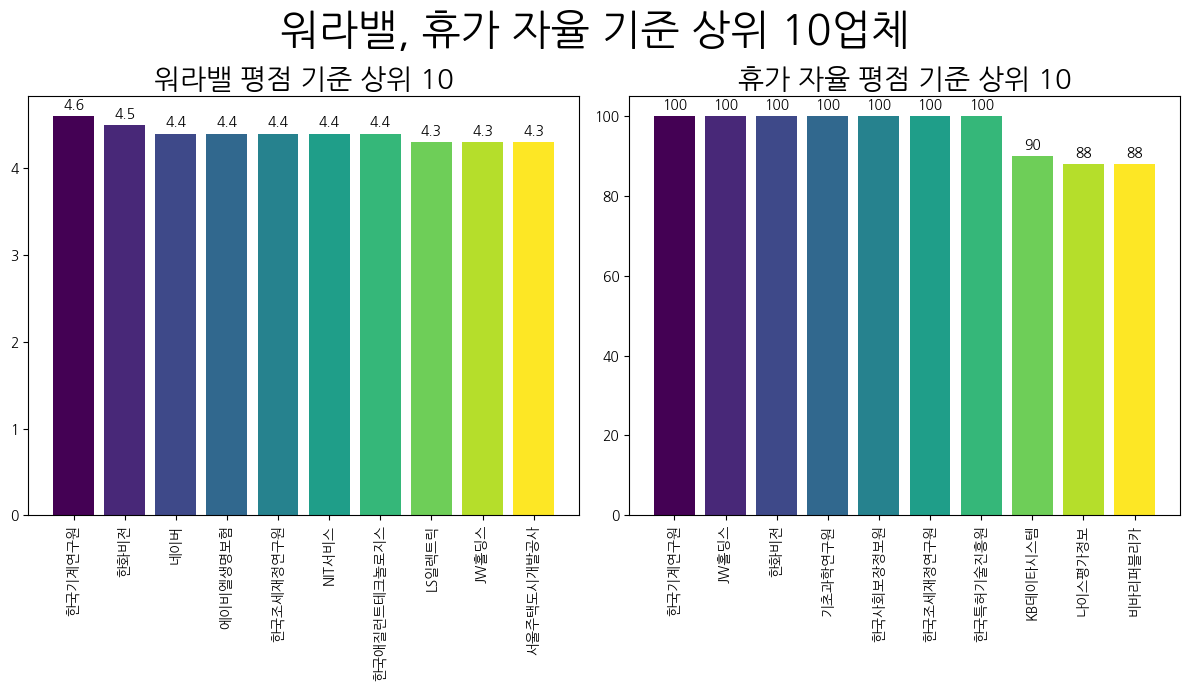

In [60]:
# 워라밸, 휴가 자율 점수 상위 15개
df_score1= df_score[['회사','워라밸']].sort_values(by = '워라밸',ascending=False)
df_score2 = df_score[['회사','리뷰3점수']].sort_values(by = '리뷰3점수',ascending=False)

cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
fig,axes = plt.subplots(1,2,figsize=(12,7))
fig.suptitle('워라밸, 휴가 자율 기준 상위 10업체',size=30)

bars1 = axes[0].bar(df_score1['회사'][:10], df_score1['워라밸'][:10],color = colors)
axes[0].bar_label(bars1, padding=3) # padding은 막대와 숫자 사이의 간격
axes[0].set_title('워라밸 평점 기준 상위 10',size=20)
axes[0].tick_params(axis='x', labelrotation=90)


bars2 = axes[1].bar(df_score2['회사'][:10], df_score2['리뷰3점수'][:10],color = colors)
axes[1].bar_label(bars2, padding=3) # padding은 막대와 숫자 사이의 간격
axes[1].set_title('휴가 자율 평점 기준 상위 10',size=20)
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\966049090.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


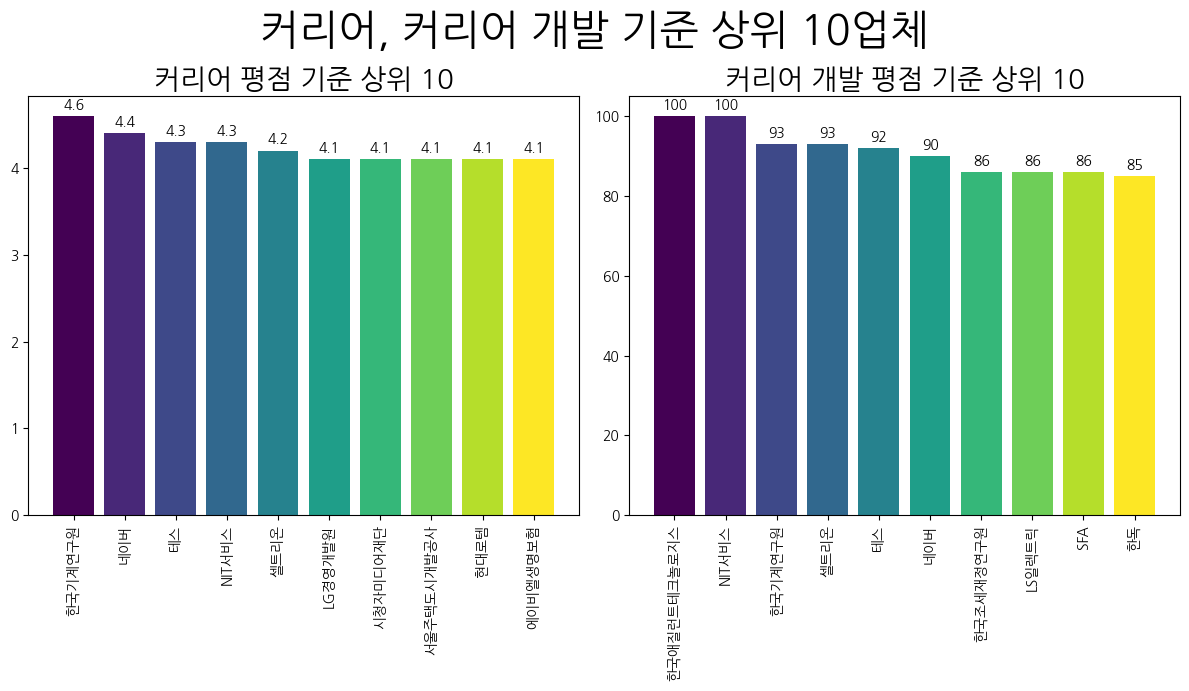

In [61]:
# 커리어, 커리어 개발 점수 상위 15개
df_score1= df_score[['회사','커리어']].sort_values(by = '커리어',ascending=False)
df_score2 = df_score[['회사','리뷰4점수']].sort_values(by = '리뷰4점수',ascending=False)

cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
fig,axes = plt.subplots(1,2,figsize=(12,7))
fig.suptitle('커리어, 커리어 개발 기준 상위 10업체',size=30)

bars1 = axes[0].bar(df_score1['회사'][:10], df_score1['커리어'][:10],color = colors)
axes[0].bar_label(bars1, padding=3) # padding은 막대와 숫자 사이의 간격
axes[0].set_title('커리어 평점 기준 상위 10',size=20)
axes[0].tick_params(axis='x', labelrotation=90)


bars2 = axes[1].bar(df_score2['회사'][:10], df_score2['리뷰4점수'][:10],color = colors)
axes[1].bar_label(bars2, padding=3) # padding은 막대와 숫자 사이의 간격
axes[1].set_title('커리어 개발 평점 기준 상위 10',size=20)
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\3939287336.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


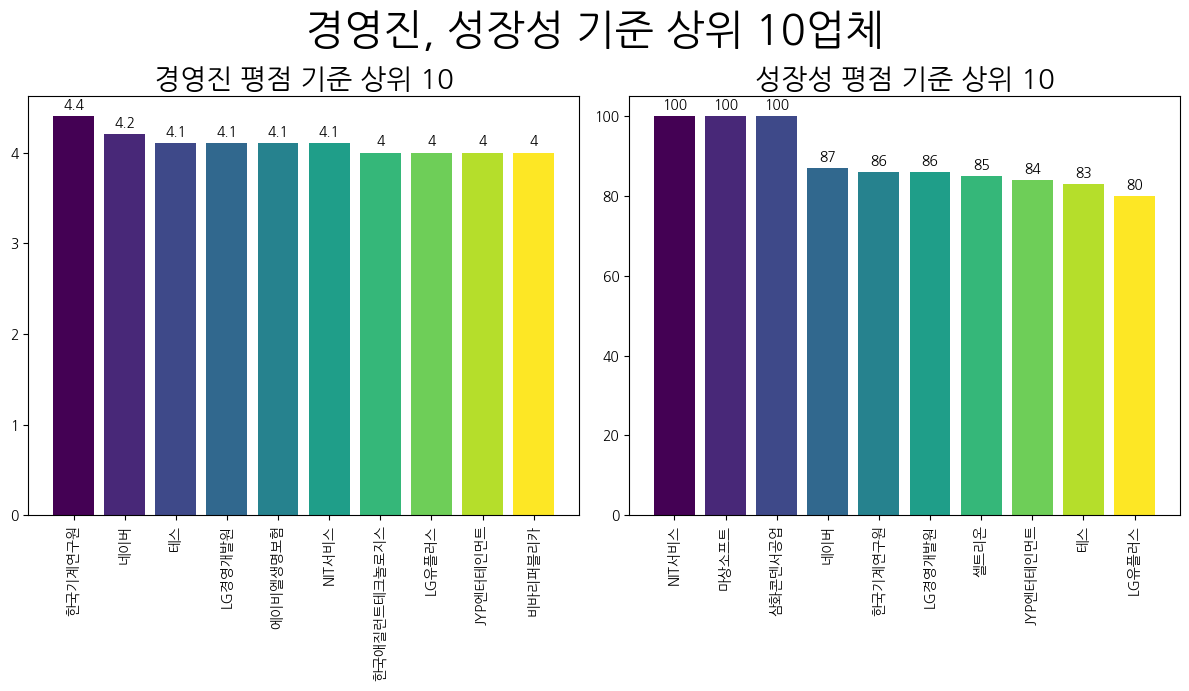

In [62]:
# 경영진, 성장성 점수 상위 15개
df_score1= df_score[['회사','경영진']].sort_values(by = '경영진',ascending=False)
df_score2 = df_score[['회사','리뷰5점수']].sort_values(by = '리뷰5점수',ascending=False)

cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
fig,axes = plt.subplots(1,2,figsize=(12,7))
fig.suptitle('경영진, 성장성 기준 상위 10업체',size=30)

bars1 = axes[0].bar(df_score1['회사'][:10], df_score1['경영진'][:10],color = colors)
axes[0].bar_label(bars1, padding=3) # padding은 막대와 숫자 사이의 간격
axes[0].set_title('경영진 평점 기준 상위 10',size=20)
axes[0].tick_params(axis='x', labelrotation=90)


bars2 = axes[1].bar(df_score2['회사'][:10], df_score2['리뷰5점수'][:10],color = colors)
axes[1].bar_label(bars2, padding=3) # padding은 막대와 숫자 사이의 간격
axes[1].set_title('성장성 평점 기준 상위 10',size=20)
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

### 잡코리아 데이터 분석

In [ ]:

df3 = pd.read_csv('jobkorea.csv')
df3

,회사,공고,업종,업무,경력,학력,스킬,조건
0,일진전기(주),2026년 일진전기 채용연계형 인턴 모집,기타 절연선 및 케이블 제조업,"전기, 경영기획, 사업기획, 재무기획, 데이터분석, 브랜드기획, 신사업기획, 연구기...",신입·경력,대졸이상 (졸업예정자 가능),NaN,"장애인, 영어능통자(원어민수준), 유관업무 경험자(인턴·알바), 보훈대상자, 석사학..."
1,샘표식품㈜,2026 샘표식품 신입/경력사원 수시채용,장류 제조업,"건강식품, 식품가공, PM, 경영기획, 문서작성, 통계·분석, 자료조사, 문서관리,...",신입·경력,학력무관,ERP,"국가유공자, 장애인, 취업보호대상자"
2,㈜인팩,`26년 1분기 인팩 그룹 채용 공고,자동차·조선·철강·항공,"결산, 관리회계, 부가세신고, 상품입출고, 창고관리, 4대보험, 거래처관리, 기구설...","신입·경력 (3년이상, 직무별 상이(상세요강 참고))",초대졸이상 ( 직무별 상이(상세요강 참고) ),"C, C++, CAD, OA, CATIA, 베트남어, 영어, MCU, MES, 물류...","장애인, 영어가능자, 인근거주자, 차량소지자, 베트남어가능자, 유관업무 경험자(인턴..."
3,㈜유도,㈜유도 신입 및 경력사원 모집,기계·기계설비,"상품입출고, 거래처관리, 조립, 회로설계, 기계, 유지보수, 임베디드, SI개발, ...",신입·경력 (직무별 상이),학력무관 ( 직무별 상이 ),"ASP.NET, C#, C++, WPF, AutoCAD","장애인, 유관업무 경험자(인턴·알바), 보훈대상자, 관련 학과 전공자, 관련 자격증..."
4,㈜넥스트칩,2026년 2월 신입/경력 수시채용,반도체·디스플레이·광학,"메카트로닉스, 생산기술, 전산입력, PCB, 신소재, 거래처관리, 펌웨어, 회로설계...","신입·경력 (2년이상, 직무별 상이)",대졸이상 ( 직무별 상이 ),"C, C++, Git, Jira, Matlab, Python, Verilog, Vi...","국가유공자, 장애인, 영어가능자, 중국어가능자, 유관업무 경험자(인턴·알바) 우대전..."
...,...,...,...,...,...,...,...,...
422,한국ICT인재개발원,[국비지원IT취업교육]JAVA파이썬/웹앱개발/프론트엔드/백엔드/풀스택/빅데이터/인공...,학원·어학원·교육원,"Java, SM, 디버깅, 모바일프로그램, 백엔드, 서버프로그램, 아키텍처 설계, ...",신입·경력,고졸이상,"AWS, Git, Hadoop, JAVA, MyBatis, MySQL, Oracle...",NaN
423,엠비씨(MBC)아카데미 컴퓨터교육센터,[서울/경기/인천/부산] 최대 전액지원 AI 무료 취업교육생과정 모집,기타 기술 및 직업훈련학원,"2D온라인게임, 3D온라인게임, 게임소프트웨어, 기업교육, 디지털디자인, 모바일, ...",신입·경력,"고졸이상 (졸업예정자 가능, 25년 졸업예정자 가능)","AR, JAVA, Spring Framework, UI, 모션 그래픽",NaN
424,엠비씨(MBC)아카데미 컴퓨터교육센터,"[서울/경기/인천/부산] 국비 전액지원 무료 취업교육생과정모집 (AI, 풀스택개발,...",기타 기술 및 직업훈련학원,"2D온라인게임, 3D디자인, 3D모델링, 3D온라인게임, 게임디자인, 게임소프트웨어...",신입·경력,"고졸이상 (졸업예정자 가능, 25년 졸업예정자 가능)","AR, JAVA, Spring Framework, UI, 모션 그래픽, 메타버스, ...",NaN
425,대한상공회의소,[전액국비] 취업연계 첨단기술 교육생 모집(반도체/AI/응용SW/로봇/스마트제조/IoT),일반 서적 출판업,"네트워크관리, 메카트로닉스, 생산기술, PCB, 빅데이터, 기구설계, 제품개발, 회...",신입·경력,학력무관,NaN,NaN


In [83]:
df3.isnull().sum()

회사      0
공고      0
업종      2
업무     18
경력      2
학력     19
스킬    147
조건    183
dtype: int64

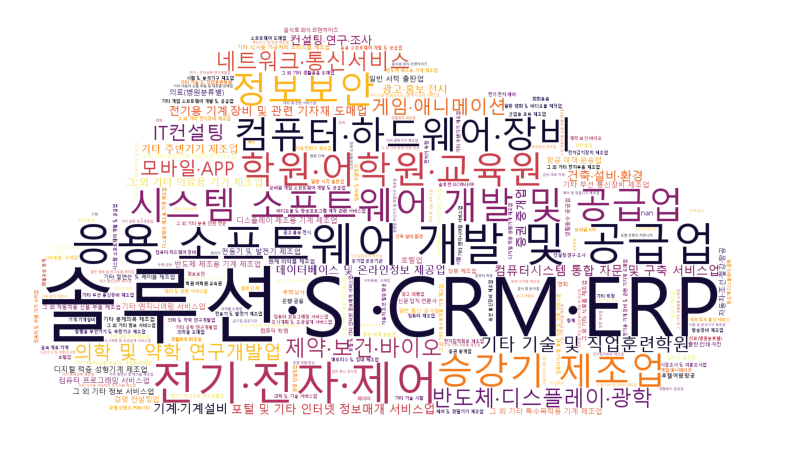

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\1276073980.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


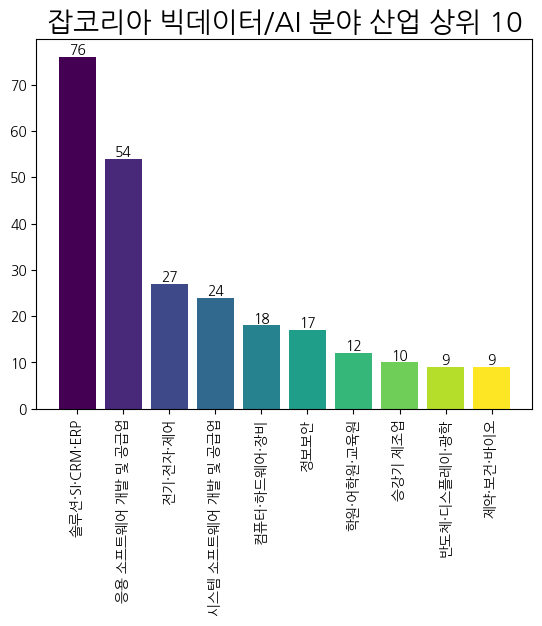

In [88]:
# word Cloud 생성
# 업종

feature_str=''
for i in df3['업종']:
    feature_str += (','+str(i))
feature_list = feature_str.split(',')
okt = Okt()
tags = Counter(feature_list)


#한글을 분석하기 위해 font를 한글로 지정
if platform.system() == 'Windows':
    path = r'c:\Windows\Fonts\malgun.ttf'
elif platform.system() == 'Darwin':
    path = r'/System/Library/Fonts/AppleGothic'
else:
    font = r'/user/share/fonts/truetype/name/NanumMyeongjo.ttf'

img_mask = np.array(Image.open('cloud.png'))
wc = WordCloud(font_path=path, width=400,height=400,
               background_color='white',max_font_size=200,
               repeat=True,
               colormap='inferno',mask=img_mask)

cloud = wc.generate_from_frequencies(dict(tags))# 딕셔너리의 value값(빈도수)에 따라 글자 크기가 달라짐
# 생성된 WordCloud를 test.jpg로 보낸다.
# cloud.to_file('test.jpg')
plt.figure(figsize=(10,8))
plt.axis('off')
plt.imshow(cloud)
plt.show()

# 업종 상위

industry_list2 = tags.most_common(10)
industrys = [industry[0] for industry in industry_list2]
counts = [industry[1] for industry in industry_list2]
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(industrys,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('잡코리아 빅데이터/AI 분야 산업 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()

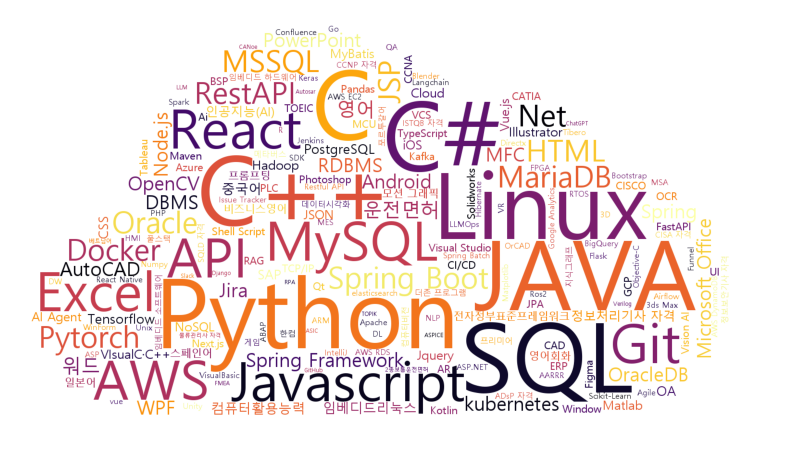

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\2776545547.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


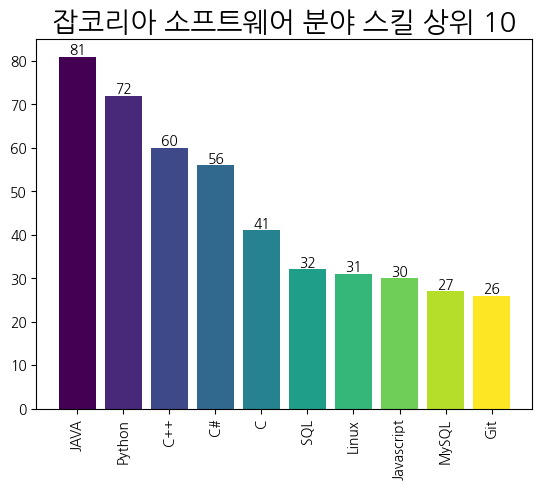

In [95]:
# word Cloud 생성
# 스킬

feature_list = []
for i in df3['스킬'].dropna():
    feature_list.extend([x.strip() for x in i.split(',')])
okt = Okt()
tags = Counter(feature_list)


#한글을 분석하기 위해 font를 한글로 지정
if platform.system() == 'Windows':
    path = r'c:\Windows\Fonts\malgun.ttf'
elif platform.system() == 'Darwin':
    path = r'/System/Library/Fonts/AppleGothic'
else:
    font = r'/user/share/fonts/truetype/name/NanumMyeongjo.ttf'

img_mask = np.array(Image.open('cloud.png'))
wc = WordCloud(font_path=path, width=400,height=400,
               background_color='white',max_font_size=200,
               repeat=True,
               colormap='inferno',mask=img_mask)

cloud = wc.generate_from_frequencies(dict(tags))# 딕셔너리의 value값(빈도수)에 따라 글자 크기가 달라짐
# 생성된 WordCloud를 test.jpg로 보낸다.
# cloud.to_file('test.jpg')

plt.figure(figsize=(10,8))
plt.axis('off')
plt.imshow(cloud)
plt.show()

skill_list2 = tags.most_common(10)
skills = [skill[0] for skill in skill_list2]
counts = [skill[1] for skill in skill_list2]
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(skills,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('잡코리아 소프트웨어 분야 스킬 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()



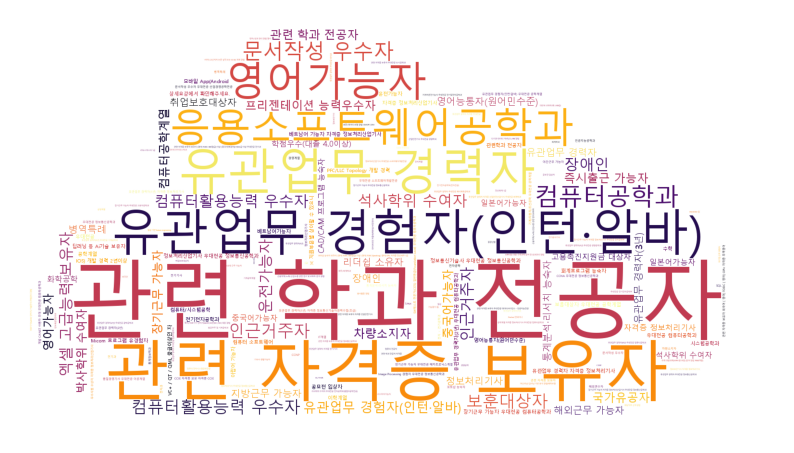

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\3836040183.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


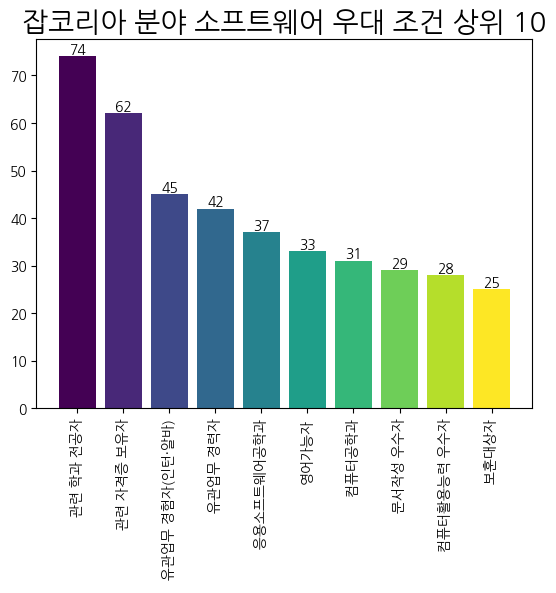

In [90]:
# word Cloud 생성
# 잡코리아
# 우대 조건

feature_str=''
for i in df3['조건'].dropna():
    feature_str += (','+str(i))
feature_list = feature_str.split(',')
okt = Okt()
tags = Counter(feature_list)


#한글을 분석하기 위해 font를 한글로 지정
if platform.system() == 'Windows':
    path = r'c:\Windows\Fonts\malgun.ttf'
elif platform.system() == 'Darwin':
    path = r'/System/Library/Fonts/AppleGothic'
else:
    font = r'/user/share/fonts/truetype/name/NanumMyeongjo.ttf'

img_mask = np.array(Image.open('cloud.png'))
wc = WordCloud(font_path=path, width=400,height=400,
               background_color='white',max_font_size=200,
               repeat=True,
               colormap='inferno',mask=img_mask)

cloud = wc.generate_from_frequencies(dict(tags))# 딕셔너리의 value값(빈도수)에 따라 글자 크기가 달라짐
# 생성된 WordCloud를 test.jpg로 보낸다.
# cloud.to_file('test.jpg')

plt.figure(figsize=(10,8))
plt.axis('off')
plt.imshow(cloud)
plt.show()

skill_list2 = tags.most_common(10)
skills = [skill[0] for skill in skill_list2]
counts = [skill[1] for skill in skill_list2]
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(skills,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('잡코리아 분야 소프트웨어 우대 조건 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()



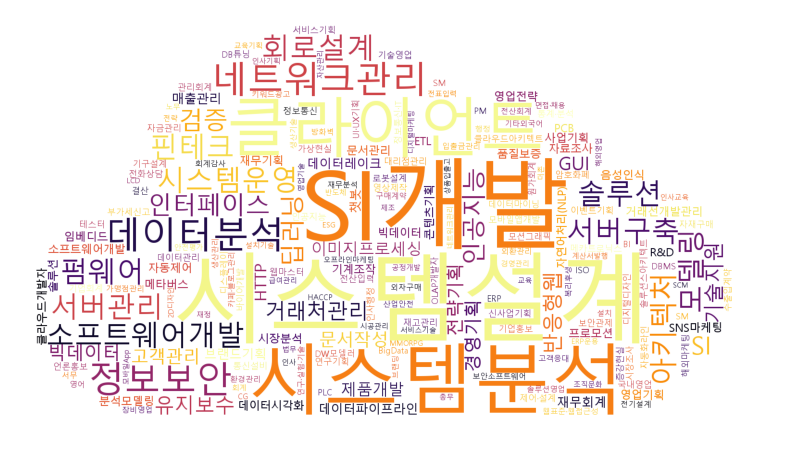

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11392\496256866.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


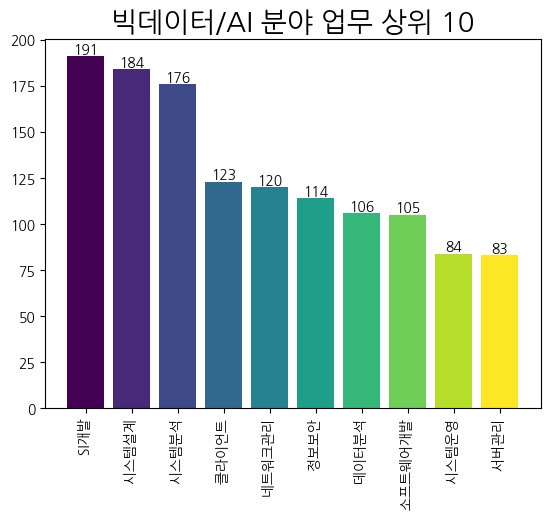

In [92]:
# word Cloud 생성
# 잡코리아
# 업무

feature_str=''
for i in df3['업무'].dropna():
    feature_str += (','+str(i))
feature_list = feature_str.split(',')
okt = Okt()
tags = Counter(feature_list)


#한글을 분석하기 위해 font를 한글로 지정
if platform.system() == 'Windows':
    path = r'c:\Windows\Fonts\malgun.ttf'
elif platform.system() == 'Darwin':
    path = r'/System/Library/Fonts/AppleGothic'
else:
    font = r'/user/share/fonts/truetype/name/NanumMyeongjo.ttf'

img_mask = np.array(Image.open('cloud.png'))
wc = WordCloud(font_path=path, width=400,height=400,
               background_color='white',max_font_size=200,
               repeat=True,
               colormap='inferno',mask=img_mask)

cloud = wc.generate_from_frequencies(dict(tags))# 딕셔너리의 value값(빈도수)에 따라 글자 크기가 달라짐
# 생성된 WordCloud를 test.jpg로 보낸다.
# cloud.to_file('test.jpg')

plt.figure(figsize=(10,8))
plt.axis('off')
plt.imshow(cloud)
plt.show()

skill_list2 = tags.most_common(10)
skills = [skill[0] for skill in skill_list2]
counts = [skill[1] for skill in skill_list2]
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

bars = plt.bar(skills,counts,color = colors)

# 막대 그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom') # ha: 수평정렬, va: 수직정렬
plt.title('빅데이터/AI 분야 업무 상위 10',size=20)
plt.xticks(rotation=90)
plt.show()
